In [1]:
import pandas as pd
import numpy as np

path = "/home/yusuf/quant/drl-crypto/data/interim/1s/ADAUSDT/ADAUSDT-1s-2025-05.parquet"
df = pd.read_parquet(path)
df.head()

,ts,price_last,buy_qty,sell_qty
0,2025-05-01 00:00:00,0.6816,1346.2,0.0
1,2025-05-01 00:00:02,0.6816,0.0,1254.9
2,2025-05-01 00:00:04,0.6816,0.0,17.5
3,2025-05-01 00:00:05,0.6816,7.4,7.4
4,2025-05-01 00:00:06,0.6818,142.6,0.0


Text(0.5, 1.0, 'Buy and Sell Flow with Price')

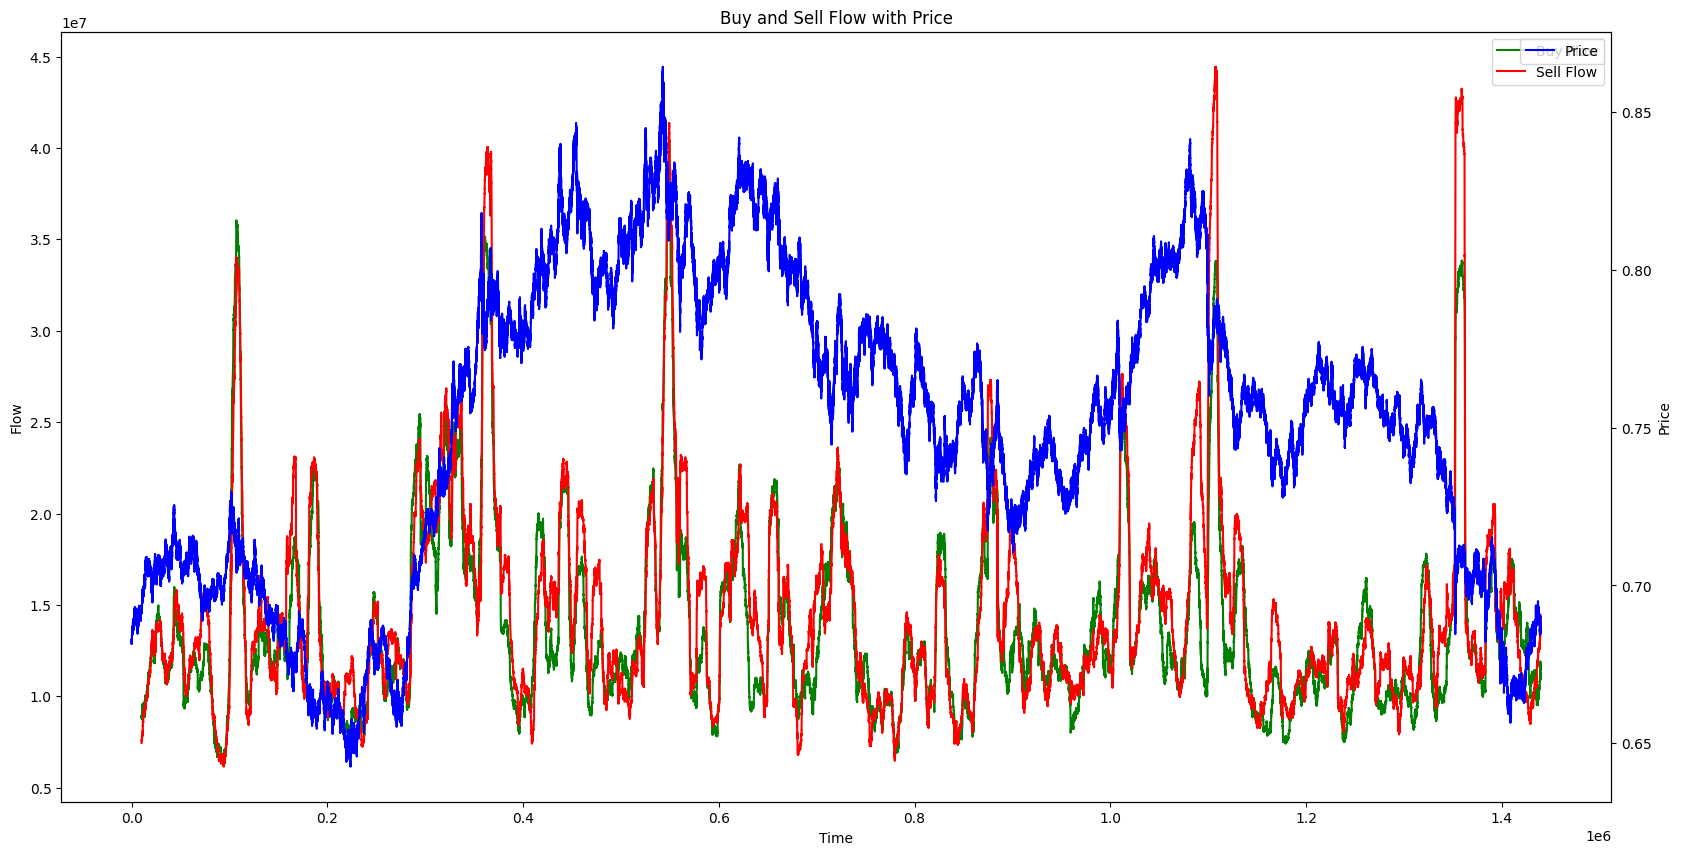

In [ ]:
n = 10000
buy_flow = df.buy_qty.rolling(n).sum()
sell_flow = df.sell_qty.rolling(n).sum()
df["buy_flow"] = buy_flow
df["sell_flow"] = sell_flow
df["ofi"] = (df.buy_flow - df.sell_flow) / (df.buy_flow + df.sell_flow)

import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(20, 10)) 
df.buy_flow.plot(ax=ax, label="Buy Flow", color="green")
df.sell_flow.plot(ax=ax, label="Sell Flow", color="red")
ax_price = ax.twinx()
df.price_last.plot(ax=ax_price, label="Price", color="blue")


ax.set_xlabel("Time")
ax.set_ylabel("Flow")
ax_price.set_ylabel("Price")
ax.legend()
ax_price.legend()
plt.title("Buy and Sell Flow with Price")




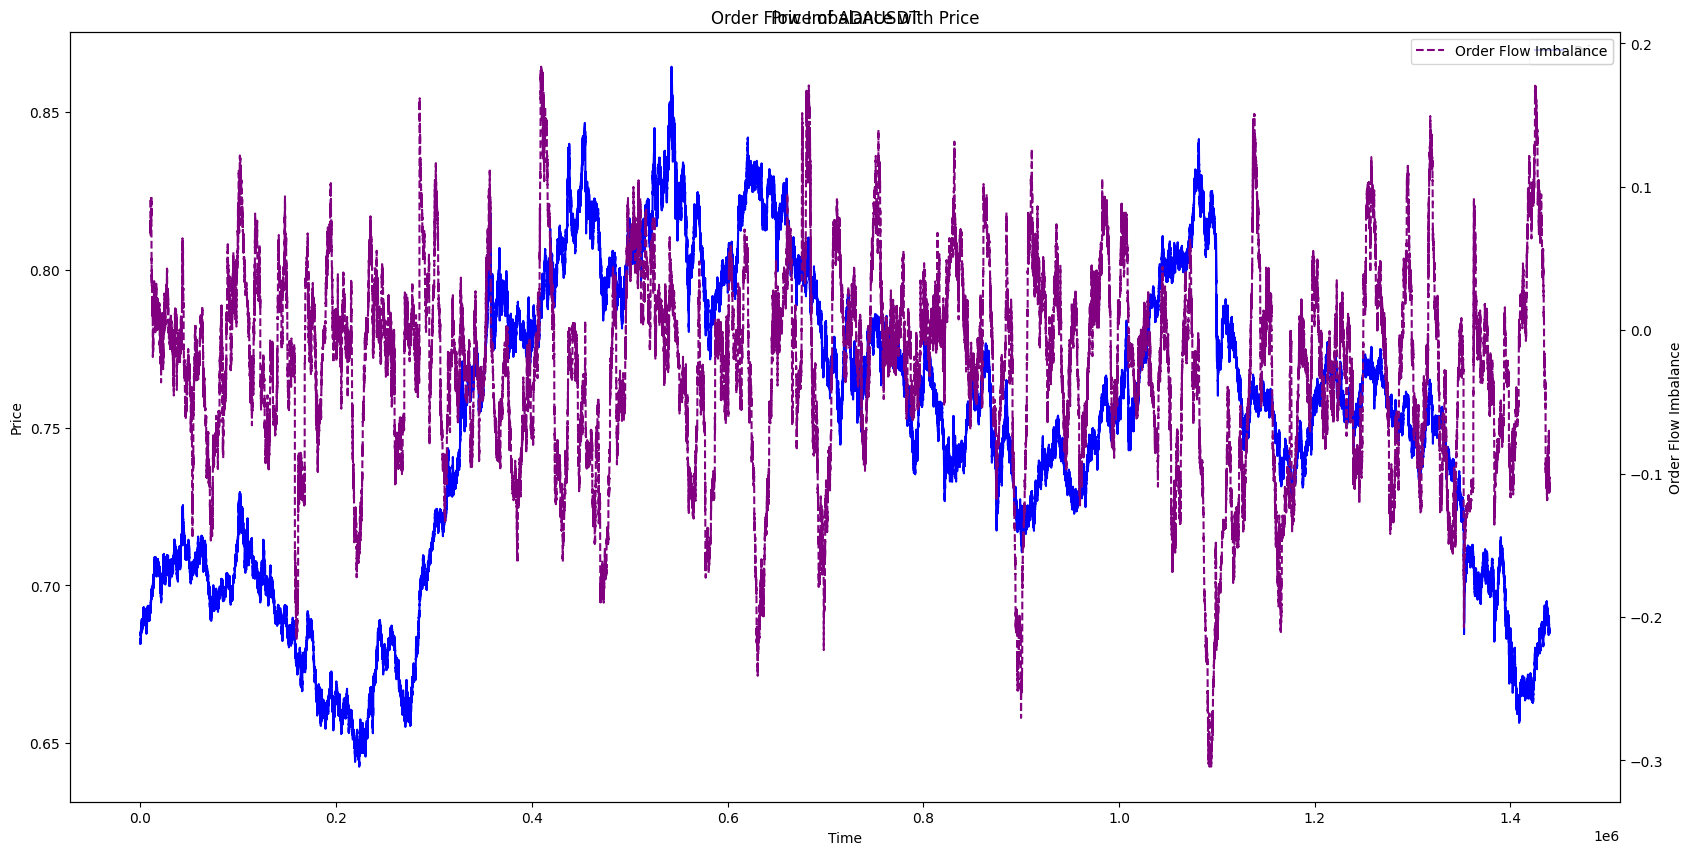

In [11]:
fig,ax = plt.subplots(figsize=(20, 10))
df.price_last.plot(ax=ax, label="Price", color="blue")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.legend()
ax.set_title("Price of ADAUSDT")
ax_ofi = ax.twinx()
df["ofi"] = (df.buy_flow - df.sell_flow) / (df.buy_flow + df.sell_flow)
df.ofi.plot(ax=ax_ofi, label="Order Flow Imbalance", color="purple", linestyle='--')
ax_ofi.set_ylabel("Order Flow Imbalance")
ax_ofi.legend()
plt.title("Order Flow Imbalance with Price")
plt.show()


In [20]:
X = pd.read_parquet("/home/yusuf/quant/drl-crypto/data/processed/1s/ADAUSDT/ADAUSDT-feat-1s-2025-05.parquet")
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1439945 entries, 0 to 1439944
Data columns (total 50 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   ts                    1439945 non-null  float32
 1   price_last            1439945 non-null  float32
 2   buy_qty               1439945 non-null  float32
 3   sell_qty              1439945 non-null  float32
 4   price_last_agg1       1439945 non-null  float32
 5   price_last_agg1_l5    1439940 non-null  float32
 6   price_last_agg1_l15   1439930 non-null  float32
 7   price_last_agg1_l60   1439885 non-null  float32
 8   price_last_agg1_l180  1439765 non-null  float32
 9   price_last_agg1_l600  1439345 non-null  float32
 10  buy_qty_agg5          1439842 non-null  float32
 11  buy_qty_agg5_l0       1439842 non-null  float32
 12  buy_qty_agg15         1439832 non-null  float32
 13  buy_qty_agg15_l0      1439832 non-null  float32
 14  buy_qty_agg60         1439787 non-